![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Explainability for Convolutional Neural Networks

In this Notebook we will show you different methods that can be used for interpreting CNN models. We will demonstrate you how to compare those methods and choose the appropriate one.

---

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your own machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. In order to start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-cnn/6-Tutorial_XAI_for_ImageAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive, and you can navigate it through the lefthand panel in Colab. You might also have received an email that informs you about the access on your Google Drive.

In [ ]:
# On Google Colab: fetch the course and install the requirements.
# Running locally this cell does nothing, because you already have the repository
# and installed the requirements yourself.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %cd /content
    !rm -rf XAI-Tutorials
    !git clone --depth 1 --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git
    %cd XAI-Tutorials
    !pip install -r requirements_xai-for-cnn.txt
    %cd xai-for-cnn


### Imports

Let's start with importing all required Python packages.

In [4]:
# Load the required packages
import json
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

import shap
from lime import lime_image

import torch
from torchvision import models
from torchvision.models.inception import Inception_V3_Weights
from skimage.segmentation import mark_boundaries

import sys
sys.path.append('./')
import utils

sys.path.append('../models/')
from model_gradcam import GradCamModel

We fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [5]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)
torch.manual_seed(seed)

---

## Data and Model Loading

We first load the image we want to analyse and the model we use for predicton.

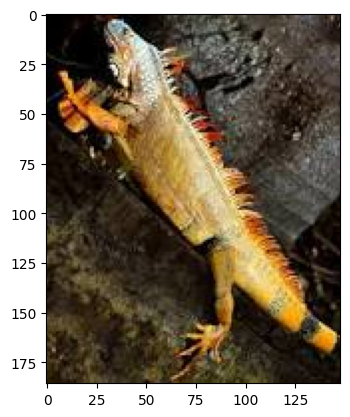

In [6]:
# read and visualize the image
path_to_img = '../data/images/Iguana.jpeg'
img = utils.read_image_cv(path_to_img)
img_PIL = utils.read_image_PIL(path_to_img)
plt.imshow(img)
plt.show()

# load the ImageNet class names
url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
fname = shap.datasets.cache(url)
with open(fname) as f:
    class_names = json.load(f)

Before we can use the image, we need to convert the image to RGB channel, transform the image (convert to PIL format, resize to lower resolution, convert to tensor dtype and normalize the pixel values), and unsqueeze the image to add a batch dimension.

In [7]:
# define the transformations (here we are using the ImageNet transformations)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

img_trans = utils.transform_img(img, mean, std)

We define a CNNs model that we will use for the classification using the ResNet50 architecture.

In [8]:
# load model
model_shap = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1).eval()
model_lime = models.inception_v3(weights=Inception_V3_Weights.DEFAULT)
model_gc = GradCamModel().eval()

## Now, what are our possibilities to explain the classification of our image?

There are two main kinds of explainability methods for images:

- occlusion- or perturbation-based methods
- gradient-based methods

The first ones consist of manipulating/masking parts of the image to generate explanations. Some examples of these are LIME and SHAP.
The second one consists of leveraging the gradient of the function so that a mapping of the function value onto multiple input dimensions is readily obtained. There are many gradient-based methods (e.g. Grad-CAM, Integrated Gradients, SmoothGradthat), which differ in how these gradients are computed.

In this tutorial, we will compare the results from Grad-CAM with the SHAP library, which combines perturbation- and gradient-based methods.

### Interpretation with GradCAM

In the [Tutorial_Grad-CAM_for_images.ipynb](./2-Tutorial_Grad-CAM_for_images.ipynb) notebook you were introduced to the model-specific Grad-CAM method. This method uses the gradients to localize the pixel in the image that are relevant for the classification, creating a heatmap that is very easy to interpret.

<font color='green'>

#### Task 1: Apply Grad-CAM to the trained ResNet50 model to explain the prediction for the iguana image. Compute the class activation (localization) map and visualize the resulting heatmap to highlight the image regions that contribute most to the prediction.

In [9]:
# Step 1: Forward Pass
logits = model_gc(img_trans) 
feat_maps = model_gc.get_activations(img_trans).detach() # get the activations of the last convolutional layer   

# Step 2: Select the Target Class
pred_class = logits.argmax(dim=1)
print(f'Classification results: {pred_class.item()}')

Classification results: 39


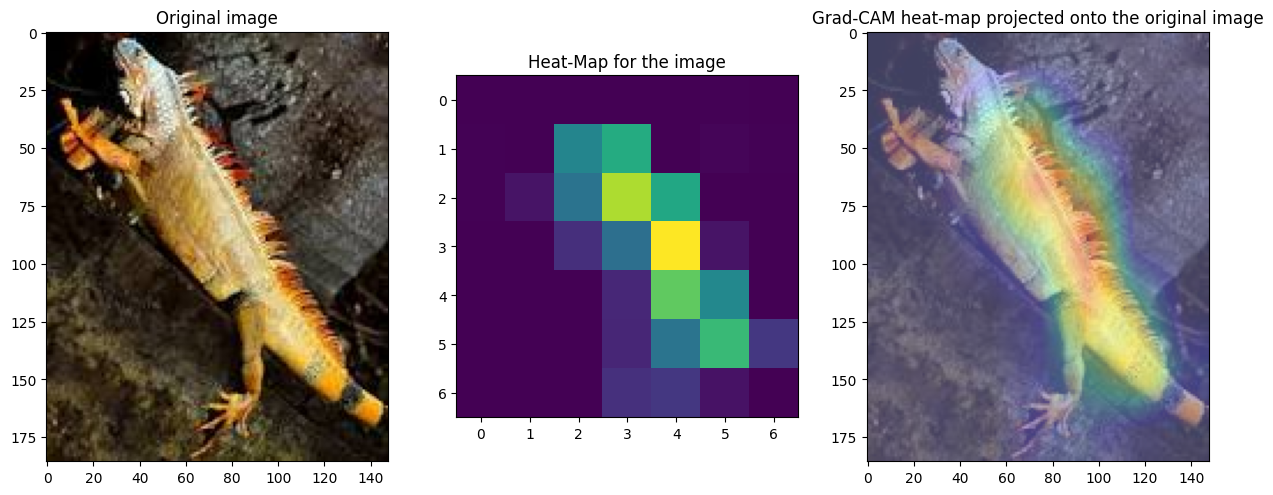

In [10]:
c = 39

# Step 3: Compute the Gradients
logits[:,c].backward(retain_graph=True) #get the gradient of the class c wrt. the feature map
gradients = model_gc.get_gradient() # pull the gradients out of the model

# Step 4: Compute the Grad-CAM
pooled_gradients = torch.mean(gradients, dim=[0, 2, 3]) # get global average pooling across the filters

for i in range(feat_maps.size(1)):
    feat_maps[:, i, :, :] *= pooled_gradients[i] # weight the filters by corresponding gradients
    
localization_map = torch.sum(feat_maps, dim=1).squeeze() # average the channels of the activations
localization_map = localization_map.numpy() # convert the map to be a numpy array
localization_map = np.maximum(localization_map, 0) # relu on top of the localization map

# Step 5: Post-processing
localization_map /= np.max(localization_map) # normalize the localization_map
heatmap = cv.resize(localization_map, (img_PIL.size[0], img_PIL.size[1])) # resize to image size
heatmap = np.uint8(255 * heatmap) # normalize to [0, 255] range and convert to unsigned int

# Step 6: Plot Results
plt.figure(figsize=(15, 15))
plt.subplot(131)
plt.imshow(img_PIL)
plt.title('Original image')
plt.subplot(132)
plt.imshow(localization_map.squeeze())
plt.title('Heat-Map for the image')
plt.subplot(133)
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.imshow(img_PIL, alpha=0.5)
plt.title('Grad-CAM heat-map projected onto the original image')
plt.show()

### Interpretation with LIME
In the [Tutorial_LIME_Images.ipynb](./4-Tutorial_LIME_Images.ipynb) we discussed how to use the LIME local interpretation method to explain the outcome of an image classification CNN model. This model uses a surrogate model trained on interpretable features obtained by perturbing the original image. Let's apply this method to our iguana image and comment on the explanations we get.

<font color='green'>

#### Task 2: Explain the ResNet50 prediction for the iguana image using LIME. Create the appropriate LIME explainer and visualize the image regions that contribute most to the model prediction.

  0%|          | 0/1000 [00:00<?, ?it/s]

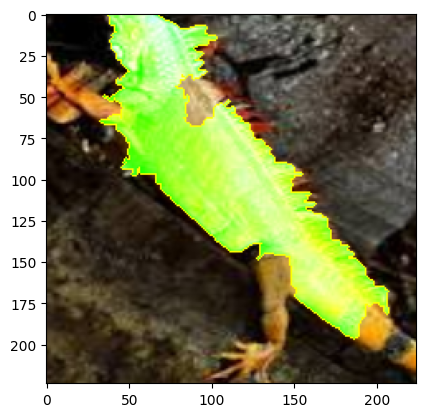

In [11]:
# Step 1: Trasform image for LIME
pill_transf = utils.get_pil_transform()
preprocess_transform = utils.get_preprocess_transform()

# Step 2: Instantiate the explainer class
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(np.array(pill_transf(img_PIL)), 
                                         lambda images: utils.batch_predict(images, model_lime), 
                                         top_labels=5, 
                                         hide_color=0, 
                                         num_samples=1000) # number of images that will be sent to classification function

# Step 3: Plot explanations
label_to_explain = 0
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[label_to_explain],
    positive_only=False,
    negative_only=False,
    num_features=5,
    hide_rest=False,)
img_boundry1 = mark_boundaries(temp/255.0, mask)
plt.imshow(img_boundry1)

<font color='green'>

#### Task 3 (Optional): As an additional exercise, investigate the other top predicted classes for the iguana image. Repeat the LIME analysis (repeat step 3 for different labels) for different predicted labels and evaluate whether the generated explanations provide meaningful and reliable insights for each class.

In [12]:
# Step 1: Select top 3 classes and respective probabilities
prediction = utils.batch_predict([pill_transf(img_PIL)], model_lime)
top_classes = prediction.argsort()[0, -5:][::-1] 
top_probabilities = prediction[0, top_classes]

Class number 39 - Probability = 1.0000


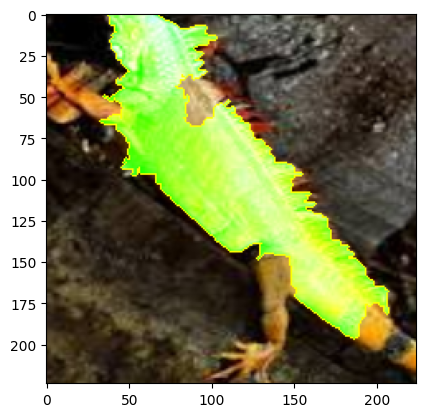

In [13]:
# Step 2: Plot explanations with explainer setup above for label 0, 1 and 2
label_to_explain = 0
print(f"Class number {top_classes[label_to_explain]} - Probability = {top_probabilities[label_to_explain]:.4f}")

temp, mask = explanation.get_image_and_mask(
        label=explanation.top_labels[label_to_explain],
        positive_only=False,
        negative_only=False,
        num_features=5,
        hide_rest=False,)
img_boundry1 = mark_boundaries(temp/255.0, mask)
plt.imshow(img_boundry1)

Class number 401 - Probability = 0.0000


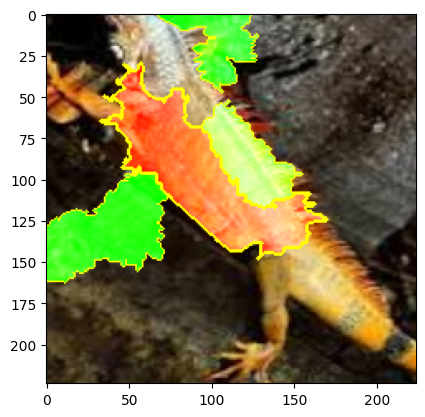

In [14]:
# Step 2: Plot explanations with explainer setup above for label 0, 1 and 2
label_to_explain = 1
print(f"Class number {top_classes[label_to_explain]} - Probability = {top_probabilities[label_to_explain]:.4f}")

temp, mask = explanation.get_image_and_mask(
        label=explanation.top_labels[label_to_explain],
        positive_only=False,
        negative_only=False,
        num_features=5,
        hide_rest=False,)
img_boundry1 = mark_boundaries(temp/255.0, mask)
plt.imshow(img_boundry1)

Class number 46 - Probability = 0.0000


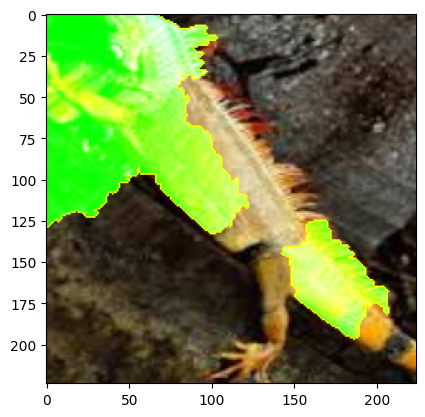

In [15]:
# Step 2: Plot explanations with explainer setup above for label 0, 1 and 2
label_to_explain = 2
print(f"Class number {top_classes[label_to_explain]} - Probability = {top_probabilities[label_to_explain]:.4f}")

temp, mask = explanation.get_image_and_mask(
        label=explanation.top_labels[label_to_explain],
        positive_only=False,
        negative_only=False,
        num_features=5,
        hide_rest=False,)
img_boundry1 = mark_boundaries(temp/255.0, mask)
plt.imshow(img_boundry1)

### Interpretation with SHAP

In the [Tutorial_SHAP_Images.ipynb](5-Tutorial_SHAP_Images.ipynb) notebook you were introduced to the model-agnostic SHAP method. Recall, with SHAP we get contrastive explanations that compare the prediction with the baseline. 

*Note: it can take some time to compute the SHAP values.*

<font color='green'>

#### Task 4: Explain the ResNet50 prediction for the iguana image using SHAP. First, create a SHAP explainer directly on the model input to obtain pixel-level explanations. Then, create a second explainer using an intermediate convolutional layer (e.g. layer4) and compare the resulting explanations. Analyze how the highlighted image regions differ between both approaches.

> **Hint:** For CNN-based image models, SHAP explanations can either be computed directly on the input pixels or on intermediate convolutional feature maps. Explaining deeper layers such as `layer4` often produces smoother and more semantically meaningful explanations because these layers capture higher-level object features instead of individual pixels. You can specify a target layer by passing both the model and the layer to the explainer:
>
> ```python id="x8j4sn"
> shap.GradientExplainer((model, model.layer4), background_data)
> ```


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].


(3, 224, 224, 4)


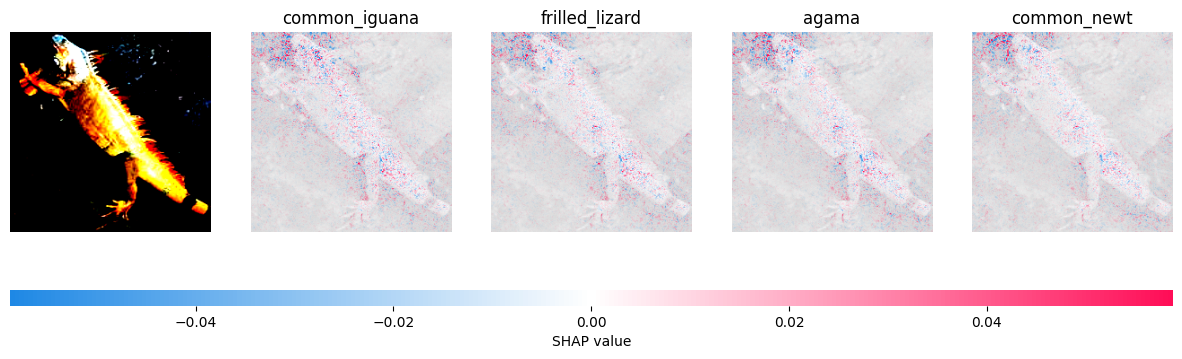

In [16]:
# Step 1. Select the background dataset for the baseline
X, y = shap.datasets.imagenet50()
background = utils.normalize_and_adjust_axes(X[:100], mean, std)

# Step 2. Instantiate the explainer class
explainer = shap.GradientExplainer(model_shap, background)

# Step 3. Compute SHAP values on custom image
shap_values, indexes = explainer.shap_values(img_trans, ranked_outputs=4)
print(shap_values[0].shape)

# Step 4. Plot results
# Step 4.1: Get class names
index_names = np.vectorize(lambda x: class_names[str(x)][1])(indexes).flatten().tolist()

# Step 4.2: Reshape SHAP values
reshaped_shap_values = []
for class_idx in range(len(index_names)):  # Iterate over the classes
    class_shap_values = []
    for img_idx in range(len(shap_values)):  # Iterate over the 3 images
        # Extract SHAP values for this class and remove singleton batch dimension
        single_image_shap = shap_values[img_idx][0, :, :, class_idx]  # Shape: (28, 28)
        class_shap_values.append(single_image_shap[..., np.newaxis])  # Add channel dimension: (28, 28, 1)
    reshaped_shap_values.append(np.array(class_shap_values))  # Combine SHAP values for this class

# Step 4.3: Transform image for plotting
img_explained_to_plot = utils.transform_img(img, mean, std, False)
shap.image_plot(reshaped_shap_values, img_explained_to_plot, index_names)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].


(1024, 14, 14, 4)


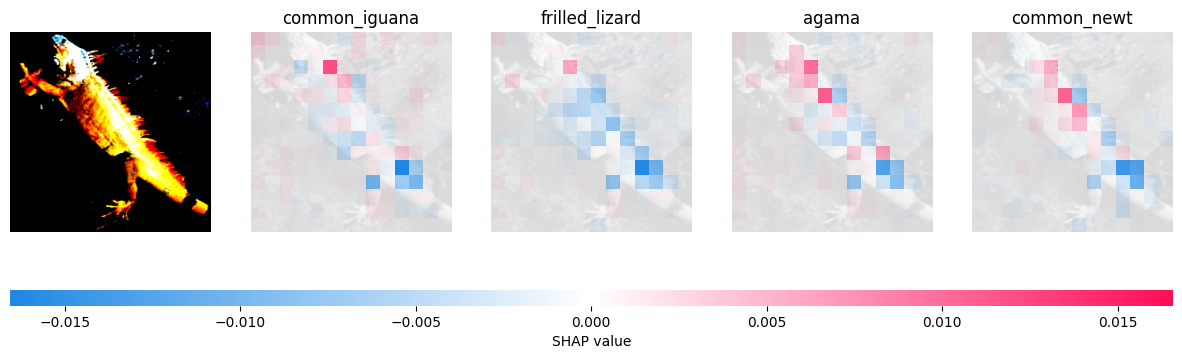

In [17]:
# Step 1. Select the background dataset for the baseline
X, y = shap.datasets.imagenet50()
background = utils.normalize_and_adjust_axes(X, mean, std)

# Step 2. Instantiate the explainer class
explainer = shap.GradientExplainer((model_shap, model_shap.layer4), background)

# Step 3. Compute SHAP values on custom image
shap_values, indexes = explainer.shap_values(img_trans, ranked_outputs=4)
print(shap_values[0].shape)

# Step 4. Plot results
# Step 4.1: Get class names
index_names = np.vectorize(lambda x: class_names[str(x)][1])(indexes).flatten().tolist()

# Step 4.2: Reshape SHAP values
reshaped_shap_values = []
for class_idx in range(len(index_names)):  # Iterate over the classes
    class_shap_values = []
    for img_idx in range(len(shap_values)):  # Iterate over the 3 images
        # Extract SHAP values for this class and remove singleton batch dimension
        single_image_shap = shap_values[img_idx][0, :, :, class_idx]  # Shape: (28, 28)
        class_shap_values.append(single_image_shap[..., np.newaxis])  # Add channel dimension: (28, 28, 1)
    reshaped_shap_values.append(np.array(class_shap_values))  # Combine SHAP values for this class

# Step 4.3: Transform image for plotting
img_explained_to_plot = utils.transform_img(img, mean, std, False)
shap.image_plot(reshaped_shap_values, img_explained_to_plot, index_names)

<font color='green'>

#### Question 1: Think about the differences between the introduced explainability methods.

<font color='grey'>

#### Your Answer: 
| Feature             | Lime                                                        | SHAP                                                            | Grad-CAM                                                        |
|---------------------|-------------------------------------------------------------|------------------------------------------------------------------|------------------------------------------------------------------|
| **Methodology**     | Perturbs input features and fits a locally linear model.    | Assigns Shapley values based on feature contributions.          | Uses gradients to highlight important image regions.            |
| **Applicability**   | Works with any black-box model.                             | Applicable to various models, including black-box models.       | Primarily designed for convolutional neural networks (CNNs).    |
| **Stability**       | May produce different explanations for the same instance.   | Provides consistent explanations for the same instance.         | Generally stable, but may vary with small changes in input.     |
| **Computation Cost**| Computationally expensive due to multiple model evaluations.| Computationally expensive.                                      | Relatively computationally efficient.                           |
| **Baseline**        | N/A                                                         | Incorporates a baseline for Shapley value computation.          | N/A                                                              |
| **Global vs. Local**| Primarily local interpretation at the instance level.       | Provides both local and global interpretation.                  | Localized interpretation at the class level.                    |


## Further Reading

### Limitations of Explainability for Image Analysis

In this section, we want to collect some examples of the limitations of those methods, to underline that it's important to use XAI methods, but not to trust them blindly. We selected three paper that we advise you to read:

**Relevance and resistance of saliency maps**: According to the paper from [Zhang et al., 2022](https://link.springer.com/chapter/10.1007/978-3-031-16437-8_43), these two parameters of saliency maps should be taken into consideration in future works to validate the trustworthiness of medical AI explainability. As shown in the picture below, different predictions might have similar or same saliency maps (lack of relevance) or the same predictions might have different saliency maps (lack of resistance).

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/raw/main/docs/source/_figures/relevance_resistance.png" width="800" /></center>

  
**Saliency Map can be misleading**: In the paper of [Rudin et al., 2018](https://arxiv.org/abs/1811.10154) the author underlines how saliency maps are often considered to be explanatory. Saliency maps can be useful to determine what part of the image is being omitted by the classifier, but this leaves out all information about how relevant information is being used. Knowing where the network is looking within the image does not tell the user what it is doing with that part of the image, as illustrated in the figure below. In fact, the saliency maps for multiple classes could be essentially the same; in that case, the explanation for why the image might contain a Siberian husky would be the same as the explanation for why the image might contain a transverse flute.
  
<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/raw/main/docs/source/_figures/Husky.png" width="800" /></center>

  
**Disagreement Problem**: As shown in the paper of [Krishna et al., 2022](https://arxiv.org/abs/2202.01602) different methods can lead to different explanations, and it's important to question which one we should consider more reliable for our task at hand.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/raw/main/docs/source/_figures/comparison.png" width="800" /></center>

### XAI as Defense Strategy

An **adversarial attack** ([Goodfellow et al., 2014](https://arxiv.org/abs/1406.2661)) consists of subtly modifying an original image in such a way that the changes are almost undetectable to the human eye. The modified image is called an adversarial image, and when submitted to a classifier is misclassified, while the original one is correctly classified.

</center>
<img src="https://miro.medium.com/v2/resize:fit:1400/format:webp/1*PmCgcjO3sr3CPPaCpy5Fgw.png" width="800"/>
</center>
<font size=1> Source: [Goodfellow et al., 2014](https://arxiv.org/abs/1412.6572)

<font color='green'>

#### Question 3: Can you think about some situations where these adversarial attacks could be very dangerous?

<font color='grey'>

#### Your Answer: 
For example:
- Autonomous driving vehicles: Traffic signs could be modified and cause an accident
- Inappropriate content: Illegal content could be modified so that it's undetectable by content moderation algorithms and used in popular websites or by police web crawlers (search engine bots download and indexes content from all over the Internet)
- Medical Diagnosis: Attackers could craft subtle perturbations in medical images that cause the classifier to misdiagnose diseases. For example, a benign lesion might be classified as malignant.
- Facial Recognition: Adversarial attacks on facial recognition systems deployed for surveillance or access control, like masking or altering faces might make people unrecognizable to facial recognition systems while appearing unchanged to human observers. Consequence: Privacy violations, unauthorized access, and identity theft could occur. Security measures relying on facial recognition may become unreliable.


Convolutional Neural Networks (CNNs), while being the cutting-edge algorithms for numerous imaging tasks, pose a challenge. These black-box models, despite their remarkable accomplishments, are not suitable for handling sensitive and critical tasks discussed earlier. To effectively implement them in these domains, addressing the fragility of these black-box models against adversarial attacks is imperative.

As shown in the figure below by [Klawikowska et al., 2020](https://link.springer.com/chapter/10.1007/978-3-030-61401-0_14) the predicted class can change after an adversarial attack, but using **explainability heatmaps can help to detect adversarial attacks** and the reason for the misclassification. The upper row contains the input images that are given to the input of the neural network, while the lower row depicts the corresponding heatmaps.

<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/raw/main/docs/source/_figures/adversarial_attacks_and_xai.png" width="800" /></center>

In panel a), we observe the original image where a Deep Neural Network (DNN) correctly classifies it as a cat with high accuracy. 
In columns b) and d), we notice the differences in the maps after adversarial attacks (Fast Gradient Sign Method (FGSM) and pixel-level attacks), leading to incorrect predictions. In the first case, the colors of the maps are flipped (and thus the pixel significance), and in the second case, it is clearly visible that the network is focusing its attention on this single, adverse pixel.

The paper introduces an **adversarial retraining strategy** (results are shown in columns c) and e)) that significantly improves results by enabling the correct classification despite the adversarial attacks.

While our focus has been on the application of XAI methods for detecting adversarial attacks, an emerging and promising research area takes a different perspective: investigating the use of adversarial attacks as a means to **evaluate the robustness of XAI methods**.

We cannot go into the details, but if you're curious, we suggest beginning your exploration with the survey of [Banieckil et al., 2022](https://arxiv.org/pdf/2306.06123.pdf).